In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import RFECV

In [4]:
df = pd.read_csv("data/archive/AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
df = df.dropna(subset=["reviews_per_month"])
X = df.drop(columns=["reviews_per_month"])
y = df["reviews_per_month"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=123
)


In [6]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,3.884300e+04,3.884300e+04,38843.000000,38843.000000,38843.000000,38843.000000,38843.000000,38843.000000,38843.000000,38843.000000
mean,1.809646e+07,6.423915e+07,40.728134,-73.951148,142.317947,5.868059,29.297557,1.373221,5.164457,114.882888
std,1.069370e+07,7.588847e+07,0.054990,0.046695,196.945624,17.384784,48.186374,1.680442,26.295665,129.543636
min,2.539000e+03,2.438000e+03,40.506410,-74.244420,0.000000,1.000000,1.000000,0.010000,1.000000,0.000000
25%,8.720027e+06,7.033824e+06,40.688640,-73.982470,69.000000,1.000000,3.000000,0.190000,1.000000,0.000000
50%,1.887146e+07,2.837193e+07,40.721710,-73.954800,101.000000,2.000000,9.000000,0.720000,1.000000,55.000000
75%,2.755482e+07,1.018465e+08,40.762990,-73.935020,170.000000,4.000000,33.000000,2.020000,2.000000,229.000000
max,3.645581e+07,2.738417e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [7]:
df.isna().sum()

id                                 0
name                               6
host_id                            0
host_name                         16
neighbourhood_group                0
neighbourhood                      0
latitude                           0
longitude                          0
room_type                          0
price                              0
minimum_nights                     0
number_of_reviews                  0
last_review                        0
reviews_per_month                  0
calculated_host_listings_count     0
availability_365                   0
dtype: int64

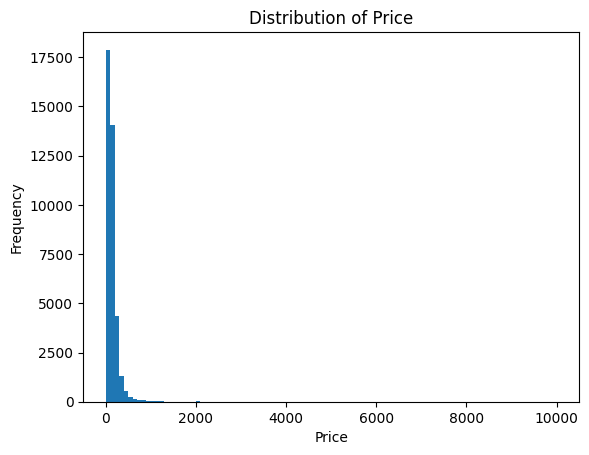

In [8]:
plt.figure()
plt.hist(df["price"], bins=100)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

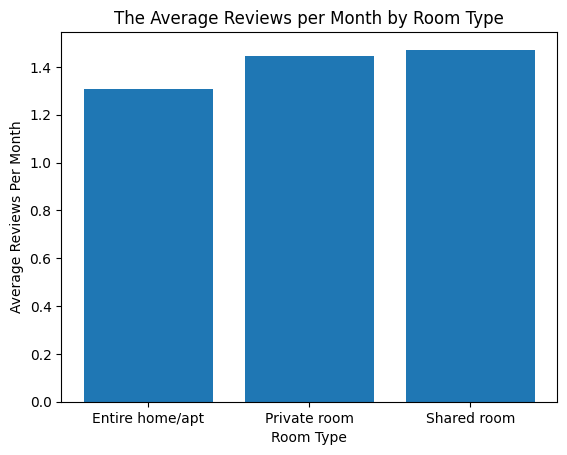

In [9]:
df_temp = df.dropna(subset=["reviews_per_month"])
room_reviews = df_temp.groupby("room_type")["reviews_per_month"].mean()
plt.figure()
plt.bar(room_reviews.index, room_reviews.values)
plt.title("The Average Reviews per Month by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Reviews Per Month")
plt.show()

In [10]:
df["price_per_minimum_night"] = df["price"] / df["minimum_nights"]
df['total_expected_reviews'] = df['availability_365'] / df['minimum_nights']
df['centrality'] = (40.7589 - df['latitude']).abs() + ( -73.9851 - df['longitude']).abs()
df['host_experience'] = df['calculated_host_listings_count'] * df['availability_365'] / 365
df['price_per_review'] = df['price'] / (df['number_of_reviews'] + 1)

In [11]:
X = df.drop(columns=["reviews_per_month","price","price_per_minimum_night"])
y = df["reviews_per_month"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=123
)

In [12]:
numeric_features = [
    "minimum_nights",
    "number_of_reviews",
    "availability_365",
    "latitude",
    "longitude",
    "total_expected_reviews",
    "centrality",
    "host_experience",
    "price_per_review"
]
categorical_features = [
    "neighbourhood_group",
    "room_type"
]
numeric_features, categorical_features

(['minimum_nights',
  'number_of_reviews',
  'availability_365',
  'latitude',
  'longitude',
  'total_expected_reviews',
  'centrality',
  'host_experience',
  'price_per_review'],
 ['neighbourhood_group', 'room_type'])

In [13]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
numeric_transformer

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
categorical_transformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [ ]:
# this is the baseline model
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
y_pred = dummy.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("Baseline:", mae)

Baseline: 1.2558884715801322


In [15]:
# training linear model
pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge())
])

param_grid = {"model__alpha": [0.01, 0.1, 1, 10, 100]}

search = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best alpha:", search.best_params_["model__alpha"])
print("Best CV MAE:", -search.best_score_)

Best alpha: 10
Best CV MAE: 0.8841021183346882


In [16]:
best_model = search.best_estimator_

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

print("CV MAE mean:", -cv_scores.mean())
print("CV MAE std:", (-cv_scores).std())
print("Individual fold MAE:", -cv_scores)

CV MAE mean: 0.8841021183346882
CV MAE std: 0.0060241664128367935
Individual fold MAE: [0.88436715 0.88151596 0.87907319 0.89559995 0.87995434]


In [17]:
models = {
    "KNN": KNeighborsRegressor(),
    "RandomForest": RandomForestRegressor(random_state=123, n_estimators=200),
    "GradientBoosting": GradientBoostingRegressor(random_state=123)
}

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    cv_out = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_error",
        return_train_score=True,
        n_jobs=-1
    )
    
    results.append({
        "model": name,
        "train_MAE_mean": (-cv_out["train_score"]).mean(),
        "test_MAE_mean": (-cv_out["test_score"]).mean(),
        "fit_time_mean": cv_out["fit_time"].mean(),
        "score_time_mean": cv_out["score_time"].mean()
    })

results_df = pd.DataFrame(results).sort_values("test_MAE_mean")
results_df

,model,train_MAE_mean,test_MAE_mean,fit_time_mean,score_time_mean
1,RandomForest,0.258908,0.701437,16.502666,0.465446
2,GradientBoosting,0.693805,0.710240,2.965540,0.008654
0,KNN,0.623456,0.770845,0.031247,0.278528


In [18]:
selector = RFECV(
    estimator=Ridge(alpha=search.best_params_["model__alpha"]),
    step=1,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

fs_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("feature_selection", selector),
    ("model", Ridge(alpha=search.best_params_["model__alpha"]))
])

cv_scores_fs = cross_validate(
    fs_pipe,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error",
    return_train_score=True,
    n_jobs=-1
)

print("Feature Selection CV MAE mean:", (-cv_scores_fs["test_score"]).mean())
print("Feature Selection CV MAE std:", (-cv_scores_fs["test_score"]).std())

Feature Selection CV MAE mean: 0.8839880246957075
Feature Selection CV MAE std: 0.0059809980752871545


In [19]:
tuned_results = []

for name, model in models.items():
    print(f"\nTuning {name}...")
    
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    param_distributions = {}
    
    if name == "KNN":
        param_distributions = {
            "model__n_neighbors": [5, 10, 15, 20, 30],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2]
        }
    elif name == "RandomForest":
        param_distributions = {
            "model__n_estimators": [200, 400, 600],
            "model__max_depth": [None, 5, 10, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2", 0.5]
        }
    elif name == "GradientBoosting":
        param_distributions = {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.01, 0.1, 0.2],
            "model__max_depth": [3, 5, 7],
            "model__min_samples_split": [2, 5, 10],
            "model__subsample": [0.8, 0.9, 1.0]
        }
    
    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_distributions,
        n_iter=20 if name != "KNN" else 15,
        cv=5,
        scoring="neg_mean_absolute_error",
        random_state=123,
        n_jobs=-1
    )
    
    search.fit(X_train, y_train)
    
    tuned_results.append({
        "model": name,
        "best_params": search.best_params_,
        "cv_mae": -search.best_score_,
        "untuned_mae": 0.701361 if name == "RandomForest" else 
                     0.710240 if name == "GradientBoosting" else 0.770845
    })
    
    print(f"Best {name} params: {search.best_params_}")
    print(f"Best {name} CV MAE: {-search.best_score_:.3f}")

tuned_df = pd.DataFrame(tuned_results)
print("\n=== TUNED RESULTS ===")
print(tuned_df[["model", "untuned_mae", "cv_mae"]].round(3))



Tuning KNN...
Best KNN params: {'model__weights': 'distance', 'model__p': 1, 'model__n_neighbors': 15}
Best KNN CV MAE: 0.728

Tuning RandomForest...


/Users/leowu555/miniforge3/envs/cpsc330/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RandomForest params: {'model__n_estimators': 600, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best RandomForest CV MAE: 0.684

Tuning GradientBoosting...


KeyboardInterrupt: 